# Mushroom Classification - GLM / Logistic Regression

Este notebook implementa el análisis del dataset Mushrooms para determinar si un hongo es comestible o venenoso utilizando regresión logística.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


Matplotlib is building the font cache; this may take a moment.


In [12]:
#Cargar dataset
cols = [
"class","cap_shape","cap_surface","cap_color","bruises","odor",
"gill_attachment","gill_spacing","gill_size","gill_color",
"stalk_shape","stalk_root","stalk_surface_above_ring",
"stalk_surface_below_ring","stalk_color_above_ring",
"stalk_color_below_ring","veil_type","veil_color",
"ring_number","ring_type","spore_print_color",
"population","habitat"
]

df = pd.read_csv(
"C:/Users/riama/OneDrive/Documentos/Laboratorio01/Data/agaricus-lepiota.data", header=None, names=cols)

df.head()


,class,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,edible,convex,smooth,white,bruises,almond,free,crowded,narrow,white,...,smooth,white,white,partial,white,one,pendant,purple,several,woods
1,edible,convex,smooth,white,bruises,almond,free,crowded,narrow,white,...,smooth,white,white,partial,white,one,pendant,brown,several,woods
2,edible,convex,smooth,white,bruises,almond,free,crowded,narrow,pink,...,smooth,white,white,partial,white,one,pendant,purple,several,woods
3,edible,convex,smooth,white,bruises,almond,free,crowded,narrow,pink,...,smooth,white,white,partial,white,one,pendant,brown,several,woods
4,edible,convex,smooth,white,bruises,almond,free,crowded,narrow,brown,...,smooth,white,white,partial,white,one,pendant,purple,several,woods


In [13]:
#Limpieza de datos
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

df.shape


(5936, 23)

In [14]:
#Convertir Variables Categóricas
le_dict = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

df.head()


,class,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,0,2,3,6,0,0,1,1,1,7,...,3,5,5,0,0,1,3,4,4,5
1,0,2,3,6,0,0,1,1,1,7,...,3,5,5,0,0,1,3,1,4,5
2,0,2,3,6,0,0,1,1,1,5,...,3,5,5,0,0,1,3,4,4,5
3,0,2,3,6,0,0,1,1,1,5,...,3,5,5,0,0,1,3,1,4,5
4,0,2,3,6,0,0,1,1,1,1,...,3,5,5,0,0,1,3,4,4,5


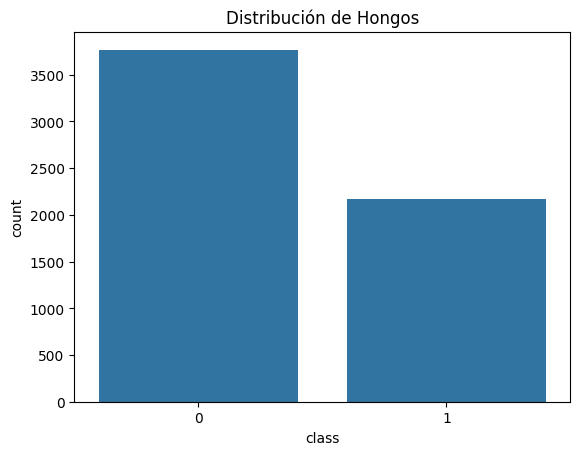

In [15]:
#Exploración de Datos
sns.countplot(x=df["class"])
plt.title("Distribución de Hongos")
plt.show()


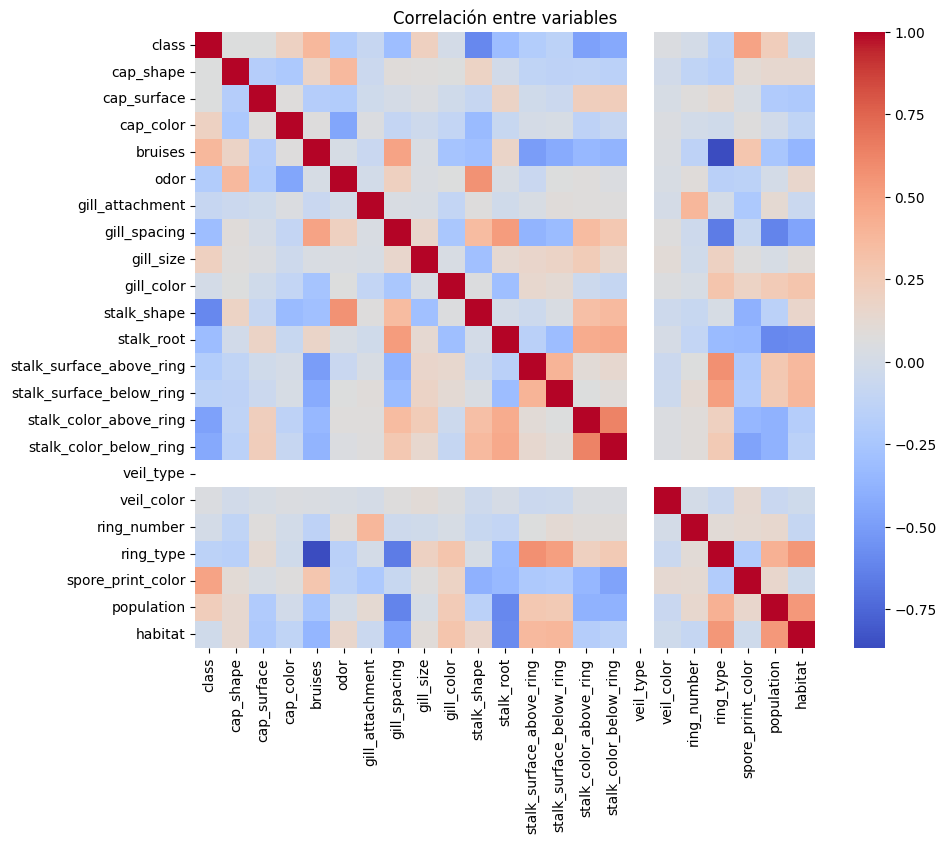

In [16]:
#Correlaciones
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlación entre variables")
plt.show()


In [17]:
#División Train / Test
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)


In [18]:
#Modelo Regresión Logística
model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
#Predicciones
pred = model.predict(X_test)



In [20]:
#Evaluación Modelo
print("Matriz de Confusión:")
print(confusion_matrix(y_test, pred))

print("\nReporte Clasificación:")
print(classification_report(y_test, pred))

print("\nAccuracy:")
print(accuracy_score(y_test, pred))


Matriz de Confusión:
[[1107   32]
 [  36  606]]

Reporte Clasificación:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1139
           1       0.95      0.94      0.95       642

    accuracy                           0.96      1781
   macro avg       0.96      0.96      0.96      1781
weighted avg       0.96      0.96      0.96      1781


Accuracy:
0.9618192026951151


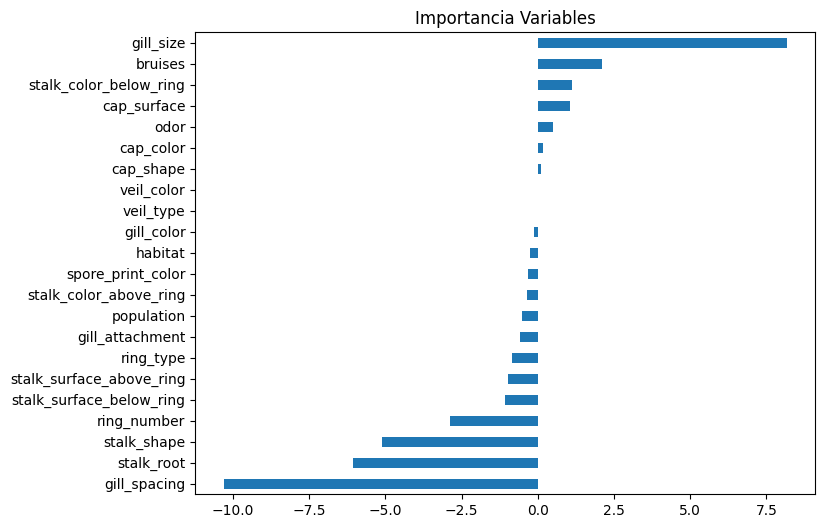

In [21]:
#Importancia Variables
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Importancia Variables")
plt.show()
